Age with screentime

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [14]:
df=pd.read_csv(r'Data\Teen_Mental_Health_Dataset.csv')
df.head(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


In [15]:
rows,columns=df.shape
print(rows) 
print(columns)

1200
13


In [16]:
print(df.isnull().sum())

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [17]:
print(df.duplicated().sum())

0


In [18]:
print(df.dtypes)

age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object


In [19]:
df['gender']                   = df['gender'].astype('category')
df['platform_usage']           = df['platform_usage'].astype('category')
df['social_interaction_level'] = df['social_interaction_level'].astype('category')
df['depression_label']         = df['depression_label'].astype('category')
df['stress_level']             = df['stress_level'].astype('category')
df['anxiety_level']            = df['anxiety_level'].astype('category')
df['addiction_level']          = df['addiction_level'].astype('category')

# Verify
print(df.dtypes)

age                            int64
gender                      category
daily_social_media_hours     float64
platform_usage              category
sleep_hours                  float64
screen_time_before_sleep     float64
academic_performance         float64
physical_activity            float64
social_interaction_level    category
stress_level                category
anxiety_level               category
addiction_level             category
depression_label            category
dtype: object


In [20]:
print(df.describe())

               age  daily_social_media_hours  sleep_hours  \
count  1200.000000               1200.000000  1200.000000   
mean     15.928333                  4.536667     6.449417   
std       2.021947                  2.029599     1.442677   
min      13.000000                  1.000000     4.000000   
25%      14.000000                  2.800000     5.200000   
50%      16.000000                  4.500000     6.500000   
75%      18.000000                  6.300000     7.600000   
max      19.000000                  8.000000     9.000000   

       screen_time_before_sleep  academic_performance  physical_activity  
count               1200.000000           1200.000000        1200.000000  
mean                   1.740333              2.990383           1.014500  
std                    0.716660              0.576758           0.582185  
min                    0.500000              2.000000           0.000000  
25%                    1.100000              2.500000           0.500000  


In [21]:
df = df.round({'daily_social_media_hours' : 2,
               'sleep_hours'              : 2,
               'screen_time_before_sleep' : 2,
               'academic_performance'     : 2,
               'physical_activity'        : 2})

print(df.head())


   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level stress_level anxiety_level addiction_level  \
0                      low            2             2        

In [32]:
age_screen = df.groupby('age')['screen_time_before_sleep'].mean().reset_index()

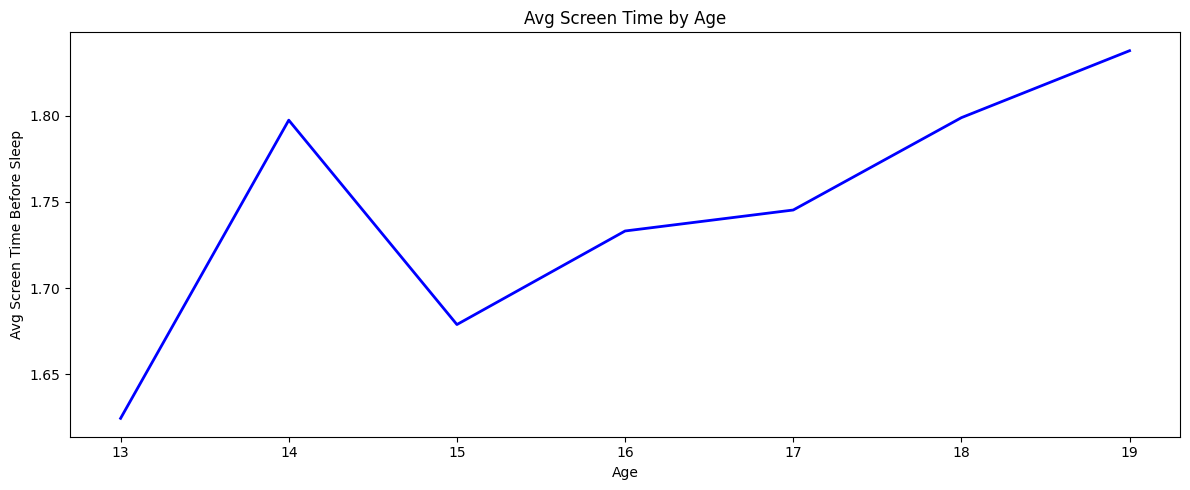

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(age_screen['age'], age_screen['screen_time_before_sleep'], 
          color='blue', linestyle='-', linewidth=2)


plt.title('Avg Screen Time by Age')
plt.xlabel('Age')
plt.ylabel('Avg Screen Time Before Sleep')
plt.tight_layout()
plt.show()